In [1]:
import numpy as np

In [3]:
!pwd

/home/marcos/Escritorio/AI-prod/Anomaly-Detection/notebooks


In [9]:


X_train = np.load("/home/marcos/Escritorio/AI-prod/Anomaly-Detection/data/servers/X_part2.npy")
X_val = np.load("/home/marcos/Escritorio/AI-prod/Anomaly-Detection/data/servers/X_val_part2.npy")
y_val = np.load("/home/marcos/Escritorio/AI-prod/Anomaly-Detection/data/servers/y_val_part2.npy")



In [12]:
X_train.shape, X_val.shape, y_val.shape

((1000, 11), (100, 11), (100,))

Assume:

X_train → mostly normal data

X_val, y_val → validation with anomalies

X_test, y_test → final evaluation

In [13]:
# scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
#X_test = scaler.transform(X_test)

In [31]:
import numpy as np

# fit on train
mu = X_train.mean(axis=0)
sigma = X_train.std(axis=0)

# avoid division by zero
sigma = np.where(sigma == 0, 1e-8, sigma)

def zscore_scores(X):
    z = np.abs((X - mu) / sigma)
    score = z.max(axis=1)  # one score per sample
    return score

In [32]:
scores_val = zscore_scores(X_val)

In [33]:
from sklearn.metrics import precision_recall_curve
import numpy as np

precision, recall, thresholds = precision_recall_curve(y_val, scores_val)

f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]
best_f1 = f1[best_idx]

print("Best threshold:", best_threshold)
print("Best F1:", best_f1)

Best threshold: 2.808592406824639
Best F1: 0.78260869073724


In [34]:
y_pred_val = scores_val > best_threshold

In [35]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_val, y_pred_val))
print("Recall:", recall_score(y_val, y_pred_val))
print("F1:", f1_score(y_val, y_pred_val))

Precision: 0.6666666666666666
Recall: 0.8
F1: 0.7272727272727273


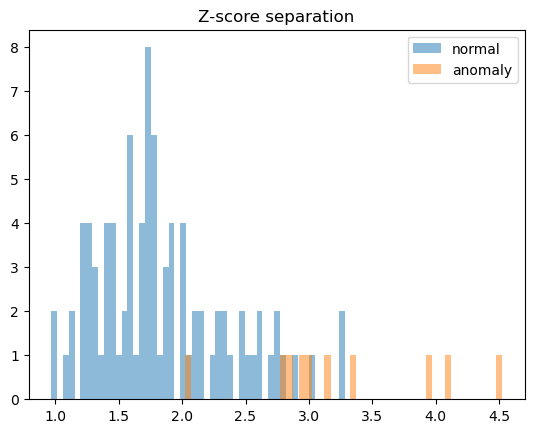

In [36]:
import matplotlib.pyplot as plt

plt.hist(scores_val[y_val == 0], bins=50, alpha=0.5, label="normal")
plt.hist(scores_val[y_val == 1], bins=50, alpha=0.5, label="anomaly")
plt.legend()
plt.title("Z-score separation")
plt.show()

## gaussian

Best threshold: 25.31279053338133
Best F1: 0.7499999953125
Precision: 1.0
Recall: 0.5
F1: 0.6666666666666666


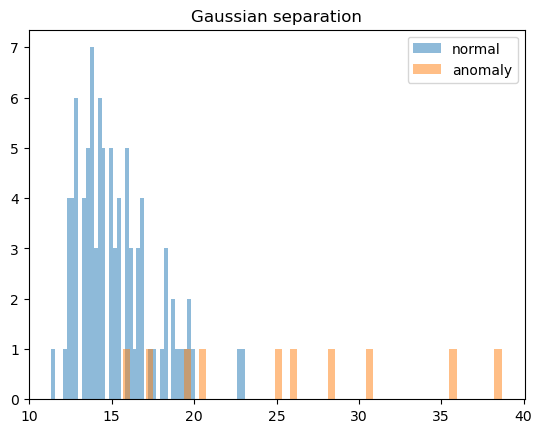

In [37]:
import numpy as np
from scipy.stats import multivariate_normal
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt


# Score = -log probability (higher = more anomalous)



# ---- Fit (train only) ----
mu = X_train.mean(axis=0)
cov = np.cov(X_train, rowvar=False)

# numerical stability (important)
cov += 1e-6 * np.eye(cov.shape[0])

model = multivariate_normal(mean=mu, cov=cov)

# ---- Score function ----
def gaussian_scores(X):
    log_probs = model.logpdf(X)
    return -log_probs  # higher = more anomalous

# ---- Validation scoring ----
scores_val = gaussian_scores(X_val)

# ---- Threshold tuning ----
precision, recall, thresholds = precision_recall_curve(y_val, scores_val)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]
print("Best threshold:", best_threshold)
print("Best F1:", f1[best_idx])

# ---- Predictions ----
y_pred_val = scores_val > best_threshold

print("Precision:", precision_score(y_val, y_pred_val))
print("Recall:", recall_score(y_val, y_pred_val))
print("F1:", f1_score(y_val, y_pred_val))

# ---- Visualization ----
plt.hist(scores_val[y_val == 0], bins=50, alpha=0.5, label="normal")
plt.hist(scores_val[y_val == 1], bins=50, alpha=0.5, label="anomaly")
plt.legend()
plt.title("Gaussian separation")
plt.show()

## isolation forest

Best threshold: -0.03368436825554122
Best F1: 0.7777777728395062
Precision: 0.8571428571428571
Recall: 0.6
F1: 0.7058823529411765


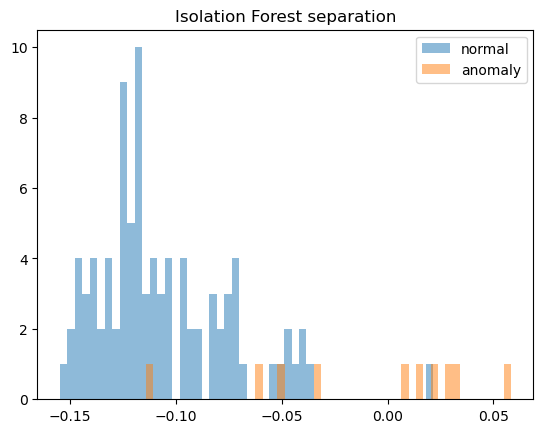

In [38]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt


#Score = -decision_function (so higher = more anomalous)


# ---- Fit (train only) ----
iso = IsolationForest(
    n_estimators=100,
    contamination=0.01,  # not critical here since we tune threshold
    random_state=42
)

iso.fit(X_train)

# ---- Score function ----
def iso_scores(X):
    scores = iso.decision_function(X)  # higher = more normal
    return -scores  # higher = more anomalous

# ---- Validation scoring ----
scores_val = iso_scores(X_val)

# ---- Threshold tuning ----
precision, recall, thresholds = precision_recall_curve(y_val, scores_val)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]
print("Best threshold:", best_threshold)
print("Best F1:", f1[best_idx])

# ---- Predictions ----
y_pred_val = scores_val > best_threshold

print("Precision:", precision_score(y_val, y_pred_val))
print("Recall:", recall_score(y_val, y_pred_val))
print("F1:", f1_score(y_val, y_pred_val))

# ---- Visualization ----
plt.hist(scores_val[y_val == 0], bins=50, alpha=0.5, label="normal")
plt.hist(scores_val[y_val == 1], bins=50, alpha=0.5, label="anomaly")
plt.legend()
plt.title("Isolation Forest separation")
plt.show()

# 1-class SVM

Best threshold: 0.29232521736974504
Best F1: 0.7619047569160999
Precision: 0.7
Recall: 0.7
F1: 0.7


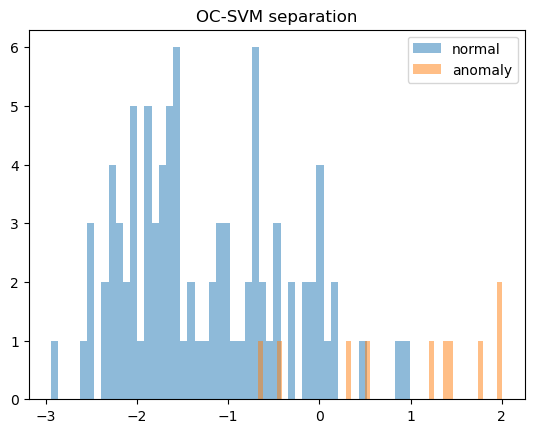

In [44]:
from sklearn.svm import OneClassSVM
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
import numpy as np
import matplotlib.pyplot as plt

# ---- IMPORTANT: scale data ----
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s = scaler.transform(X_val)

# ---- Fit (train only) ----
ocsvm = OneClassSVM(
    kernel='rbf',
    nu=0.05,       # expected anomaly fraction (tune lightly)
    gamma='scale'  # can try 'auto' or float later
)

ocsvm.fit(X_train_s)

# ---- Score function ----
def ocsvm_scores(X):
    X_s = scaler.transform(X)
    scores = ocsvm.decision_function(X_s)  # higher = more normal
    return -scores  # higher = more anomalous

# ---- Validation scoring ----
scores_val = ocsvm_scores(X_val)

# ---- Threshold tuning ----
precision, recall, thresholds = precision_recall_curve(y_val, scores_val)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]
print("Best threshold:", best_threshold)
print("Best F1:", f1[best_idx])

# ---- Predictions ----
y_pred_val = scores_val > best_threshold

print("Precision:", precision_score(y_val, y_pred_val))
print("Recall:", recall_score(y_val, y_pred_val))
print("F1:", f1_score(y_val, y_pred_val))

# ---- Visualization ----
plt.hist(scores_val[y_val == 0], bins=50, alpha=0.5, label="normal")
plt.hist(scores_val[y_val == 1], bins=50, alpha=0.5, label="anomaly")
plt.legend()
plt.title("OC-SVM separation")
plt.show()

In [45]:
for nu in [0.01, 0.05, 0.1]:
    for gamma in ['scale', 'auto']:
        ocsvm = OneClassSVM(kernel='rbf', nu=nu, gamma=gamma)
        ocsvm.fit(X_train_s)
        
        scores_val = -ocsvm.decision_function(X_val_s)
        
        precision, recall, thresholds = precision_recall_curve(y_val, scores_val)
        f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
        
        print(f"nu={nu}, gamma={gamma}, best F1={f1.max():.4f}")

nu=0.01, gamma=scale, best F1=0.7619
nu=0.01, gamma=auto, best F1=0.7619
nu=0.05, gamma=scale, best F1=0.7619
nu=0.05, gamma=auto, best F1=0.7619
nu=0.1, gamma=scale, best F1=0.7619
nu=0.1, gamma=auto, best F1=0.7619


# autoencoder

Best threshold: 2.8230364
Best F1: 0.7499999953125
Precision: 1.0
Recall: 0.5
F1: 0.6666666666666666


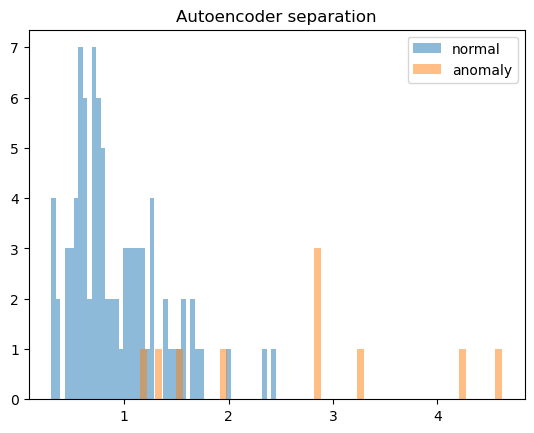

In [66]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# ---- Model ----
class AE(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 8),
            nn.ReLU(),
            nn.Linear(8, 4)
        )
        self.decoder = nn.Sequential(
            nn.Linear(4, 8),
            nn.ReLU(),
            nn.Linear(8, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = AE(X_train.shape[1])

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

# ---- Train (only normal data) ----
X_t = torch.tensor(X_train, dtype=torch.float32)

for epoch in range(50):
    optimizer.zero_grad()
    recon = model(X_t)
    loss = criterion(recon, X_t)
    loss.backward()
    optimizer.step()

# ---- Score function ----
def ae_scores(X):
    X_t = torch.tensor(X, dtype=torch.float32)
    recon = model(X_t).detach()
    error = ((X_t - recon) ** 2).mean(dim=1).numpy()
    return error

# ---- Validation scoring ----
scores_val = ae_scores(X_val)

# ---- Threshold tuning ----
precision, recall, thresholds = precision_recall_curve(y_val, scores_val)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]
print("Best threshold:", best_threshold)
print("Best F1:", f1[best_idx])

# ---- Predictions ----
y_pred_val = scores_val > best_threshold

print("Precision:", precision_score(y_val, y_pred_val))
print("Recall:", recall_score(y_val, y_pred_val))
print("F1:", f1_score(y_val, y_pred_val))

# ---- Visualization ----
plt.hist(scores_val[y_val == 0], bins=50, alpha=0.5, label="normal")
plt.hist(scores_val[y_val == 1], bins=50, alpha=0.5, label="anomaly")
plt.legend()
plt.title("Autoencoder separation")
plt.show()

# GMM

Best threshold: 25.82514892917735
Best F1: 0.7499999953125
Precision: 1.0
Recall: 0.5
F1: 0.6666666666666666


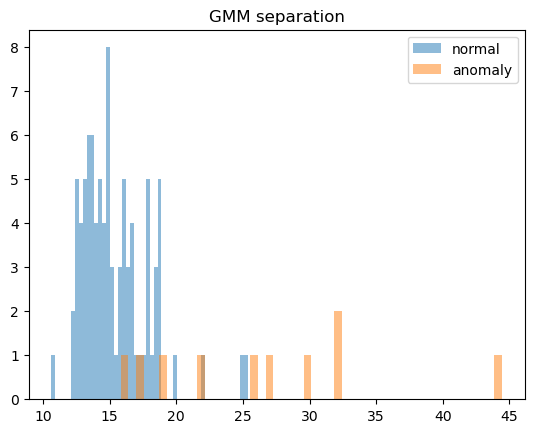

In [40]:
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt


#Score = -log likelihood (higher = more anomalous)

# ---- Fit (train only) ----
gmm = GaussianMixture(
    n_components=3,       # try 2–5 later
    covariance_type='full',
    random_state=42
)

gmm.fit(X_train)

# ---- Score function ----
def gmm_scores(X):
    log_probs = gmm.score_samples(X)  # log likelihood
    return -log_probs  # higher = more anomalous

# ---- Validation scoring ----
scores_val = gmm_scores(X_val)

# ---- Threshold tuning ----
precision, recall, thresholds = precision_recall_curve(y_val, scores_val)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]
print("Best threshold:", best_threshold)
print("Best F1:", f1[best_idx])

# ---- Predictions ----
y_pred_val = scores_val > best_threshold

print("Precision:", precision_score(y_val, y_pred_val))
print("Recall:", recall_score(y_val, y_pred_val))
print("F1:", f1_score(y_val, y_pred_val))

# ---- Visualization ----
plt.hist(scores_val[y_val == 0], bins=50, alpha=0.5, label="normal")
plt.hist(scores_val[y_val == 1], bins=50, alpha=0.5, label="anomaly")
plt.legend()
plt.title("GMM separation")
plt.show()

In [42]:
# diif comps.
for k in [1, 2, 3, 4, 5]:
    gmm = GaussianMixture(n_components=k, covariance_type='full', random_state=42)
    gmm.fit(X_train)
    
    scores_val = -gmm.score_samples(X_val)
    
    precision, recall, thresholds = precision_recall_curve(y_val, scores_val)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    print(f"k={k}, best F1={f1.max():.4f}")

k=1, best F1=0.7500
k=2, best F1=0.7619
k=3, best F1=0.7500
k=4, best F1=0.7778
k=5, best F1=0.7059


# VAE

Best threshold: 1.8858681
Best F1: 0.7999999950000002
Precision: 0.7777777777777778
Recall: 0.7
F1: 0.7368421052631579


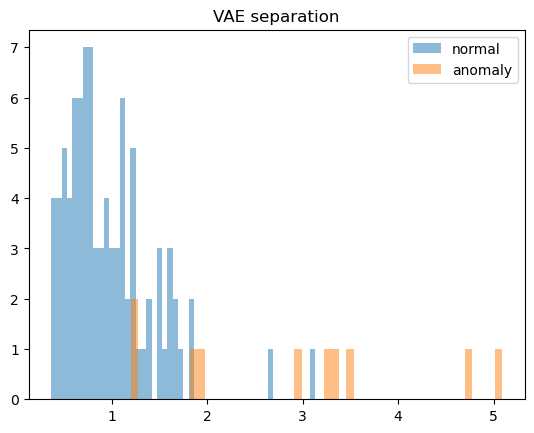

In [43]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import precision_recall_curve, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# ---- Model ----
class VAE(nn.Module):
    def __init__(self, input_dim, latent_dim=2):
        super().__init__()
        
        # encoder
        self.fc1 = nn.Linear(input_dim, 8)
        self.fc_mu = nn.Linear(8, latent_dim)
        self.fc_logvar = nn.Linear(8, latent_dim)
        
        # decoder
        self.fc2 = nn.Linear(latent_dim, 8)
        self.fc3 = nn.Linear(8, input_dim)

    def encode(self, x):
        h = torch.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = torch.relu(self.fc2(z))
        return self.fc3(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        recon = self.decode(z)
        return recon, mu, logvar

model = VAE(X_train.shape[1], latent_dim=2)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ---- Loss ----
def vae_loss(recon, x, mu, logvar):
    recon_loss = ((x - recon) ** 2).mean()
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + kl

# ---- Train ----
X_t = torch.tensor(X_train, dtype=torch.float32)

for epoch in range(50):
    optimizer.zero_grad()
    recon, mu, logvar = model(X_t)
    loss = vae_loss(recon, X_t, mu, logvar)
    loss.backward()
    optimizer.step()

# ---- Score function ----
def vae_scores(X):
    X_t = torch.tensor(X, dtype=torch.float32)
    recon, _, _ = model(X_t)
    error = ((X_t - recon) ** 2).mean(dim=1).detach().numpy()
    return error

# ---- Validation scoring ----
scores_val = vae_scores(X_val)

# ---- Threshold tuning ----
precision, recall, thresholds = precision_recall_curve(y_val, scores_val)
f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = np.argmax(f1)

best_threshold = thresholds[best_idx]
print("Best threshold:", best_threshold)
print("Best F1:", f1[best_idx])

# ---- Predictions ----
y_pred_val = scores_val > best_threshold

print("Precision:", precision_score(y_val, y_pred_val))
print("Recall:", recall_score(y_val, y_pred_val))
print("F1:", f1_score(y_val, y_pred_val))

# ---- Visualization ----
plt.hist(scores_val[y_val == 0], bins=50, alpha=0.5, label="normal")
plt.hist(scores_val[y_val == 1], bins=50, alpha=0.5, label="anomaly")
plt.legend()
plt.title("VAE separation")
plt.show()

In [60]:
# Feature contribution
import numpy as np

#Simple version (works for any model)

def feature_contribution(X, scores_fn):
    baseline = scores_fn(X)
    contributions = []

    for j in range(X.shape[1]):
        X_perturbed = X.copy()
        X_perturbed[:, j] = X[:, j].mean()  # remove signal of feature j
        
        new_scores = scores_fn(X_perturbed)
        contrib = baseline - new_scores  # how much score drops
        contributions.append(contrib)

    return np.array(contributions)  # shape: (features, samples)

In [62]:
# use if
contribs = feature_contribution(X_val, iso_scores)

# average contribution per feature (on anomalies only)
mean_contrib = contribs[:, y_val == 1].mean(axis=1)

print("Feature importance:", mean_contrib)

"""
👉 Interpretation:

high value → feature drives anomaly detection
"""

Feature importance: [0.02823554 0.0114716  0.00815475 0.00974422 0.006919   0.01317897
 0.00635742 0.01041662 0.01724754 0.0202571  0.01654654]


'\n👉 Interpretation:\n\nhigh value → feature drives anomaly detection\n'

In [63]:
# synthetica anomalies
X_syn = X_val.copy()
y_syn = y_val.copy()

# inject anomalies (single feature)
n = 50
X_syn[:n, 0] += 5  # shift feature 0 strongly
y_syn[:n] = 1

In [64]:
# multi-feature

X_syn2 = X_val.copy()
y_syn2 = y_val.copy()

n = 50
X_syn2[:n] += np.random.normal(0, 0.5, size=X_syn2[:n].shape)
y_syn2[:n] = 1

In [67]:
# eval models
def eval_on_data(scores_fn, X, y):
    scores = scores_fn(X)
    
    precision, recall, thresholds = precision_recall_curve(y, scores)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    return f1.max()

print("ISO (single feature):", eval_on_data(iso_scores, X_syn, y_syn))
print("AE (multi feature):", eval_on_data(ae_scores, X_syn2, y_syn2))

ISO (single feature): 0.8709677369992196
AE (multi feature): 0.7301587252393551


In [68]:
# iso for. stability

from sklearn.ensemble import IsolationForest

f1_scores = []

for seed in [0, 1, 2, 3, 4]:
    iso = IsolationForest(random_state=seed)
    iso.fit(X_train)
    
    scores = -iso.decision_function(X_val)
    
    precision, recall, thresholds = precision_recall_curve(y_val, scores)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    f1_scores.append(f1.max())

print("F1 scores:", f1_scores)
print("Mean:", np.mean(f1_scores), "Std:", np.std(f1_scores))

F1 scores: [0.7368421002770082, 0.7499999953125, 0.7368421002770082, 0.699999995, 0.8421052581717452]
Mean: 0.7531578898076523 Std: 0.0474969017788279


In [69]:
# autoncoder stability

f1_scores = []

for seed in [0, 1, 2]:
    torch.manual_seed(seed)
    
    model = AE(X_train.shape[1])
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    
    # train quickly
    X_t = torch.tensor(X_train, dtype=torch.float32)
    for _ in range(50):
        optimizer.zero_grad()
        recon = model(X_t)
        loss = ((X_t - recon) ** 2).mean()
        loss.backward()
        optimizer.step()
    
    scores = ae_scores(X_val)
    
    precision, recall, thresholds = precision_recall_curve(y_val, scores)
    f1 = 2 * (precision * recall) / (precision + recall + 1e-8)
    
    f1_scores.append(f1.max())

print("AE F1:", f1_scores)

AE F1: [0.7499999953125, 0.7499999953125, 0.7777777728395062]


IFNS test

In [ ]:
#https://chatgpt.com/c/69dd4431-d500-83e9-a75f-8ad87670ad9d